In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from utils import map_ordered_items_to_prices, sum_prices, has_none_value, summary_orders_df, summary_abandoned_df, extract_hour

In [2]:
DATA_DIR = Path('../../datasets/module_2/')

In [3]:
inventory = pd.read_parquet(Path(DATA_DIR, 'inventory.parquet'))
inventory.head()

,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]


In [4]:
orders = pd.read_parquet(Path(DATA_DIR, 'orders.parquet'))
orders.head()

,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


In [5]:
regulars = pd.read_parquet(Path(DATA_DIR, 'regulars.parquet'))
regulars.head()

,user_id,variant_id,created_at
3,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33618848088196,2020-04-30 15:07:03
11,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667178659972,2020-05-05 23:34:35
18,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33619009208452,2020-04-30 15:07:03
46,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667305373828,2020-05-05 23:34:35
47,4594e99557113d5a1c5b59bf31b8704aafe5c7bd180b32...,33667247341700,2020-05-06 14:42:11


In [6]:
abandoned_carts = pd.read_parquet(Path(DATA_DIR, 'abandoned_carts.parquet'))
abandoned_carts

,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"
...,...,...,...,...
70036,22233840976004,2e989bfdec87ef55ea464a529f323ff53dad2a2fc48655...,2022-03-13 14:11:15,"[34284950192260, 39466620911748]"
70041,22233843171460,b2d867b982b14ca517f27c4ced727c8a25c01b96ebbd96...,2022-03-13 14:11:36,"[39536607395972, 39506484461700]"
70043,22233843531908,220aafc0749f209b3f0f7cfe4134a5136815d48f0bbd9a...,2022-03-13 14:11:41,"[39482337624196, 39544243650692]"
70049,22233846218884,a4da55d51052411e54f98e1b90b19843121866abeaea76...,2022-03-13 14:12:09,"[34415989325956, 33667297017988, 3948233762419..."


In [7]:
users = pd.read_parquet(Path(DATA_DIR, 'users.parquet'))
users

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
2160,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1123,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1958,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN
675,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4694,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3011,2c0eaa81411d8796e4e28a1a13265aa773e815d83e6db1...,Proposition,UKH,2022-01-18 10:10:39,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4343,bf8da3ba3538396b70564a49f55f26303af645a0fe32fa...,Top Up,UKI,2021-11-02 09:24:55,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2725,b1892f28d8bb191138ec1f098a8e229c16755f2616aea0...,Top Up,UKM,2021-06-10 12:46:07,2021-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4340,2745667201081b389e4b290565d17651b3eb94d9077183...,Proposition,UKI,2021-01-10 11:07:16,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN


### Brainstorm of ideas to explore
- Are there any of the orders related to a specific region? (D)
- Are the same products bought over time?
- How much money is bought in average? (D)
- Are there any recurrent users that buy most of the purchases? Where do they belong? What time do they buy? Any seasonal patterns?
- Do similar exercise for abandoned carts? Any specific users? Any time of the day? 
### TODO: 
- list to columns in product type...

### Let's add monetary value to orders and abandoned_carts...

In [8]:
orders["items_prices"] = map_ordered_items_to_prices(orders, inventory, "ordered_items")
orders["values_not_mapped"] = orders["items_prices"].apply(has_none_value)
orders["items_total_price"] = orders["items_prices"].apply(sum_prices)

In [9]:
abandoned_carts["abandoned_prices"] = map_ordered_items_to_prices(abandoned_carts, inventory, "variant_id")
abandoned_carts["values_not_mapped"] = abandoned_carts["abandoned_prices"].apply(has_none_value)
abandoned_carts["abandoned_total_price"] = abandoned_carts["abandoned_prices"].apply(sum_prices)
abandoned_carts.head()

,id,user_id,created_at,variant_id,abandoned_prices,values_not_mapped,abandoned_total_price
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762...","[None, None, None, None, 4.09, None, 1.19, Non...",True,36.31
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326...","[3.99, 3.8, 2.58, 3.99, 2.09, 3.9, 3.0, 2.0, 2...",False,27.84
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088...","[13.0, 5.25, 4.0, None, 4.0, None, 3.0, 3.4, 2...",True,91.26
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397...","[6.0, 2.59, None, 3.5, 2.09, 20.0, 5.59, 4.5, ...",True,62.46
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]","[19.99, 7.5, 2.75]",False,30.24


In [10]:
orders["values_not_mapped"].value_counts()

values_not_mapped
True     6723
False    2050
Name: count, dtype: int64

It seems like the mapping of items is not effective for old transactions. Older products might not be referrenced correctly in the inventory...

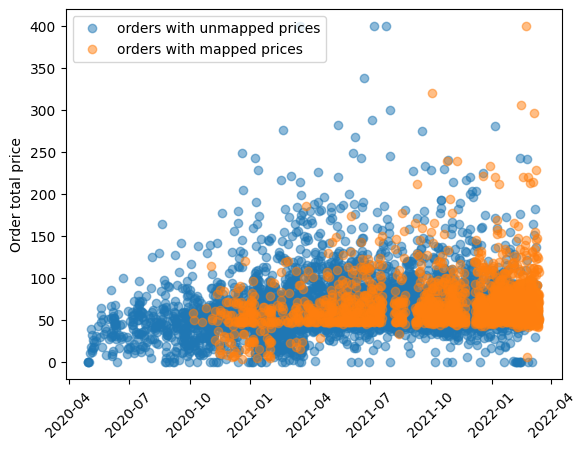

In [11]:
orders_with_prices = orders[orders["values_not_mapped"]==False]
orders_without_prices = orders[orders["values_not_mapped"]==True]
plt.xticks(rotation=45)
plt.plot(orders_without_prices["created_at"], orders_without_prices["items_total_price"], 'o', alpha=0.5, label="orders with unmapped prices")
plt.plot(orders_with_prices["created_at"], orders_with_prices["items_total_price"], 'o', alpha=0.5, label="orders with mapped prices")
plt.ylabel("Order total price")
plt.legend()

In [12]:
abandoned_carts["values_not_mapped"].value_counts()

values_not_mapped
False    4236
True     1221
Name: count, dtype: int64

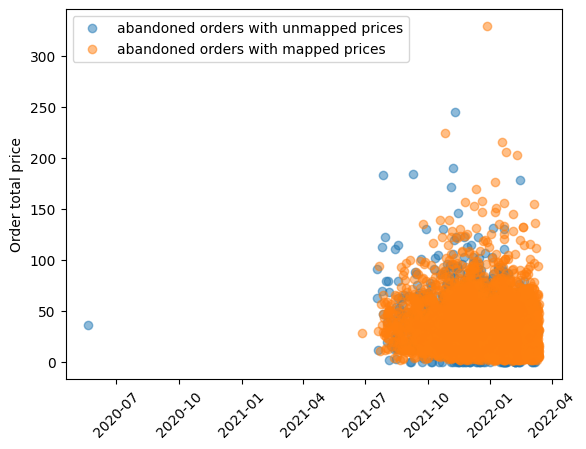

In [13]:
abandoned_carts_with_prices = abandoned_carts[abandoned_carts["values_not_mapped"]==False]
abandoned_carts_without_prices = abandoned_carts[abandoned_carts["values_not_mapped"]==True]
plt.xticks(rotation=45)
plt.plot(abandoned_carts_without_prices["created_at"], abandoned_carts_without_prices["abandoned_total_price"], 'o', alpha=0.5, label="abandoned orders with unmapped prices")
plt.plot(abandoned_carts_with_prices["created_at"], abandoned_carts_with_prices["abandoned_total_price"], 'o', alpha=0.5, label="abandoned orders with mapped prices")
plt.ylabel("Order total price")
plt.legend()

For the orders dataframe there seems to be:
- Minimum purchase price for the order or a free delivery above ~50 pounds (implemented after April 2021)
- INFLATION! (assuming users buy the same things to live....)

For the abandone dataframe it's interesting to know that the timeframe in which is being tracked is different from the orders dataframe (probably Data team was only paying attention to realized orders?).
Let's try to plot everything together...

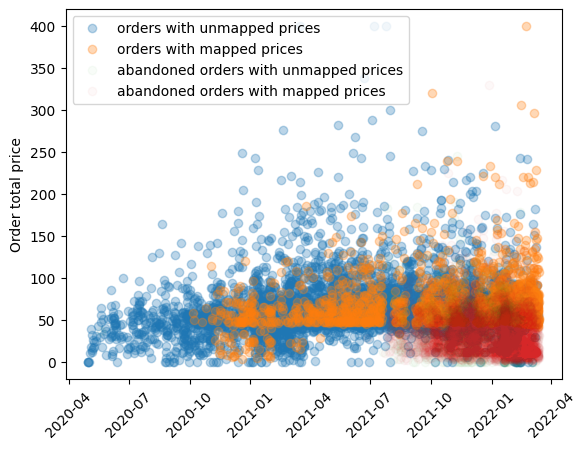

In [14]:
plt.xticks(rotation=45)
plt.plot(orders_without_prices["created_at"], orders_without_prices["items_total_price"], 'o', alpha=0.3, label="orders with unmapped prices")
plt.plot(orders_with_prices["created_at"], orders_with_prices["items_total_price"], 'o', alpha=0.3, label="orders with mapped prices")
plt.plot(abandoned_carts_without_prices["created_at"], abandoned_carts_without_prices["abandoned_total_price"], 'o', alpha=0.03, label="abandoned orders with unmapped prices")
plt.plot(abandoned_carts_with_prices["created_at"], abandoned_carts_with_prices["abandoned_total_price"], 'o', alpha=0.03, label="abandoned orders with mapped prices")
plt.ylabel("Order total price")
plt.legend()

The total price of abandoned orders has problems reaching the minimum order of ~50 pounds... 

80% of the abandoned orders have problems filling the 50 pound budget...

- Is the implementation of regular elements a posible solution to encourage order completion?
- Is the checkout process easily implemented?
- Are the fees of orders so high that it does not compensate to order below 50...?
- Do these orders belong to any region in which the fees are higher?

In [15]:
percentage_below_50 = (abandoned_carts_with_prices[abandoned_carts_with_prices["abandoned_total_price"] < 50].shape[0] / abandoned_carts_with_prices.shape[0]) * 100
print(f"Percentage of abandoned sale not reaching 50 pounds: {percentage_below_50:.1f}%")

Percentage of abandoned sale not reaching 50 pounds: 78.8%


### User distribution

In [16]:
user_orders_summary = summary_orders_df(orders)
user_orders_summary.sort_values('num_orders', ascending=False).head()

,user_id,num_orders,total_spent
3663,ba7176c5f870cd86e51ecc4375e0becc8cc305845e70b9...,25,1969.72
84,04e9d7967f4dfd7d40175f130f1c80f62204ff697df92d...,22,2231.10
319,114e78a8909ad3f9d481e66563998301eff9e7cd1b2d00...,22,1439.61
3267,a655b992a3ee5f6aa9f5ab5662c4befac1fdc45c99885b...,21,1991.31
346,1296e1e72f7f43ff28d7d285f880ad4d213fa8139233c7...,21,1505.30


In [17]:
user_abandoned_summary = summary_abandoned_df(abandoned_carts)
user_abandoned_summary.sort_values('num_orders', ascending=False).head()

,user_id,num_orders,total_abandoned
497,257be7ae940425880bbb20bf162c2616b32881bf0a8bda...,10,342.82
399,1dacfd2a360677052d8605f843ae410dd23b0ddb7f506c...,9,620.06
3438,fffd9f989509e36d1fc3e3e53627d6341482f385052a03...,7,144.21
2041,97e81469f5758878f4d7eaa3af6b4fc37b2b5c22558811...,7,310.39
227,111d37baa4fb9dde7c557b4057dfd7eff8205dc0e27190...,7,261.43


Are loyal users also susceptible to have "abandoned" orders?

In [18]:
user_summary = pd.merge(user_abandoned_summary, user_orders_summary, on='user_id', how='outer', suffixes=('_abandoned', '_ordered'))
user_summary.head()

,user_id,num_orders_abandoned,total_abandoned,num_orders_ordered,total_spent
0,0001d93f7e96bcb713aa8c5283258b5c3a80a7062fbcaf...,2.0,44.50,1,52.07
1,0011d59295eaf3ef5809aba64f2401f11e76f5bf602207...,NaN,NaN,1,100.61
2,002abde5718600d5d4cb567ff36deb2d6fb81460257769...,NaN,NaN,1,79.96
3,002b3799fded362f631b8238fa2a477a7673e1181b2756...,1.0,34.94,1,70.53
4,002fda98daf90c44ceb8601c93f504108afc2d3cdd5d00...,2.0,65.14,1,71.67


Text(0, 0.5, 'Percentage of abandoned orders')

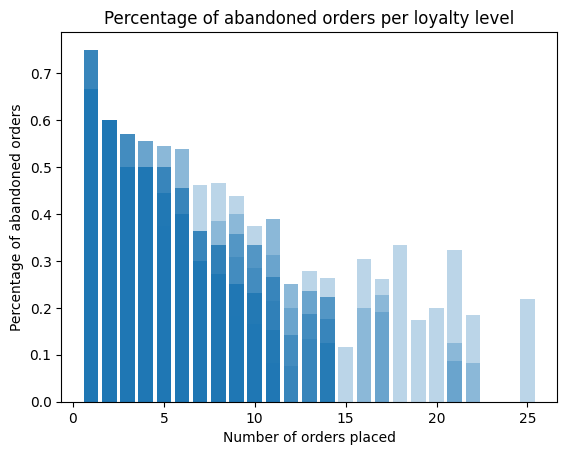

In [19]:
plt.bar(user_summary["num_orders_ordered"], user_summary["num_orders_abandoned"]/(user_summary["num_orders_ordered"]+user_summary["num_orders_abandoned"]), alpha=0.3)
plt.title("Percentage of abandoned orders per loyalty level")
plt.xlabel("Number of orders placed")
plt.ylabel("Percentage of abandoned orders")

In [20]:
user_summary.head()

,user_id,num_orders_abandoned,total_abandoned,num_orders_ordered,total_spent
0,0001d93f7e96bcb713aa8c5283258b5c3a80a7062fbcaf...,2.0,44.50,1,52.07
1,0011d59295eaf3ef5809aba64f2401f11e76f5bf602207...,NaN,NaN,1,100.61
2,002abde5718600d5d4cb567ff36deb2d6fb81460257769...,NaN,NaN,1,79.96
3,002b3799fded362f631b8238fa2a477a7673e1181b2756...,1.0,34.94,1,70.53
4,002fda98daf90c44ceb8601c93f504108afc2d3cdd5d00...,2.0,65.14,1,71.67


In [21]:
user_summary = pd.merge(user_summary, users, on='user_id', how='left')
user_summary.head()

,user_id,num_orders_abandoned,total_abandoned,num_orders_ordered,total_spent,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
0,0001d93f7e96bcb713aa8c5283258b5c3a80a7062fbcaf...,2.0,44.50,1,52.07,Top Up,UKH,2021-12-03 07:31:44,2021-12-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1,0011d59295eaf3ef5809aba64f2401f11e76f5bf602207...,NaN,NaN,1,100.61,Proposition,UKI,2021-04-02 12:17:57,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2,002abde5718600d5d4cb567ff36deb2d6fb81460257769...,NaN,NaN,1,79.96,Top Up,UKI,2021-05-01 17:28:56,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
3,002b3799fded362f631b8238fa2a477a7673e1181b2756...,1.0,34.94,1,70.53,Proposition,UKJ,2021-11-03 23:58:01,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4,002fda98daf90c44ceb8601c93f504108afc2d3cdd5d00...,2.0,65.14,1,71.67,Proposition,UKC,2022-01-25 22:26:10,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN


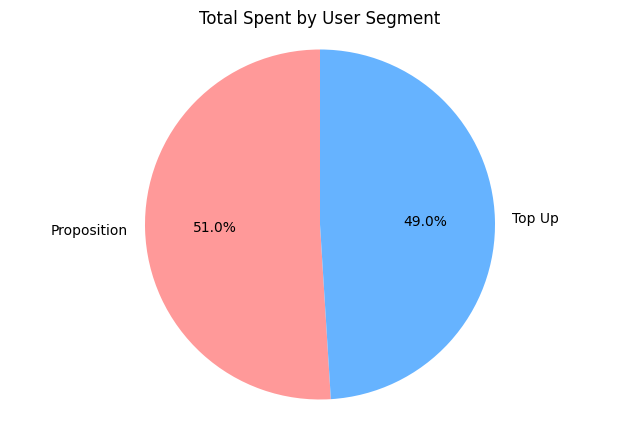

In [30]:
summary = user_summary.groupby('user_segment')['total_spent'].sum().reset_index()
summary.columns = ['User Segment', 'Total Spent']

fig, ax = plt.subplots(figsize=(8, 5))
ax.pie(summary['Total Spent'], labels=summary['User Segment'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Total Spent by User Segment')
plt.show()

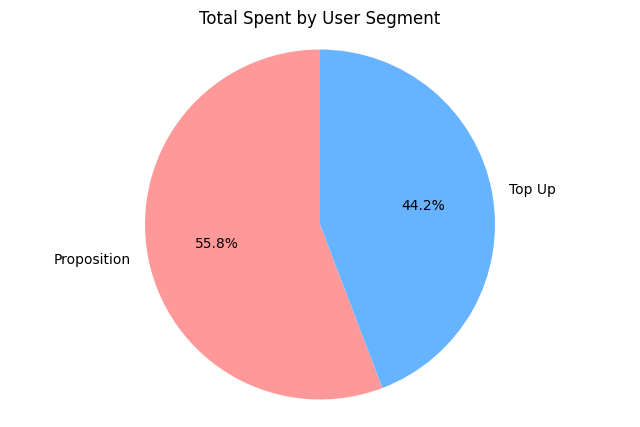

In [31]:
summary = user_summary.groupby('user_segment')['total_abandoned'].sum().reset_index()
summary.columns = ['User Segment', 'Total Spent']

fig, ax = plt.subplots(figsize=(8, 5))
ax.pie(summary['Total Spent'], labels=summary['User Segment'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Total Spent by User Segment')
plt.show()

Loyal customers tend to abandon less their orders... Tackling less loyal customers could see bigger returns?

Any patterns within faithful users vs less loyal?

In [22]:
orders = extract_hour(orders, 'created_at', 'order_hour')
abandoned_carts = extract_hour(abandoned_carts, 'created_at', 'order_hour')

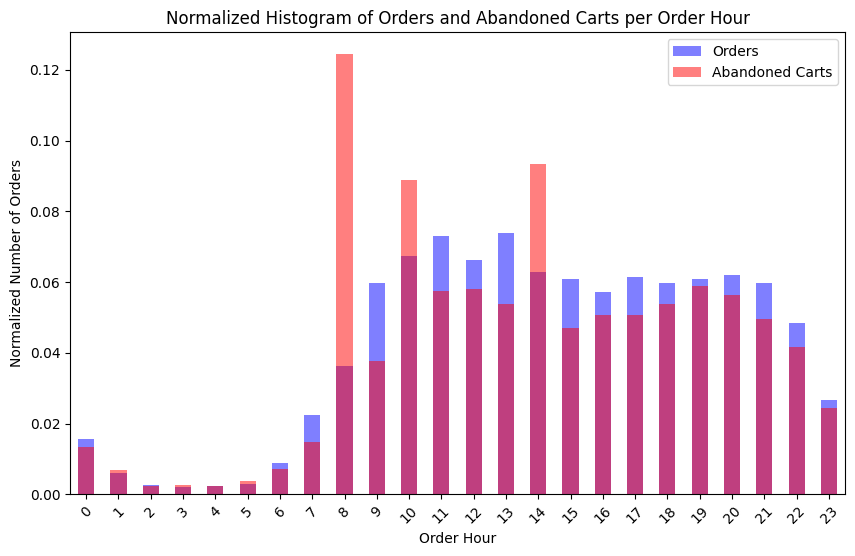

In [23]:
# Normalize the values
orders_hour_counts = orders['order_hour'].value_counts().sort_index()
abandoned_carts_hour_counts = abandoned_carts['order_hour'].value_counts().sort_index()

orders_hour_counts_normalized = orders_hour_counts / orders_hour_counts.sum()
abandoned_carts_hour_counts_normalized = abandoned_carts_hour_counts / abandoned_carts_hour_counts.sum()

fig, ax = plt.subplots(figsize=(10, 6))
orders_hour_counts_normalized.plot(kind='bar', alpha=0.5, color='blue', label='Orders', ax=ax)
abandoned_carts_hour_counts_normalized.plot(kind='bar', alpha=0.5, color='red', label='Abandoned Carts', ax=ax)

plt.xlabel('Order Hour')
plt.ylabel('Normalized Number of Orders')
plt.title('Normalized Histogram of Orders and Abandoned Carts per Order Hour')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [19]:
users_summary = pd.merge(users, user_orders_summary, on='user_id', how='left')
users_summary.head()

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets,num_orders,total_spent
0,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1,42.00
1,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1,60.00
2,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1,61.15
3,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN,10,616.64
4,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1,63.98


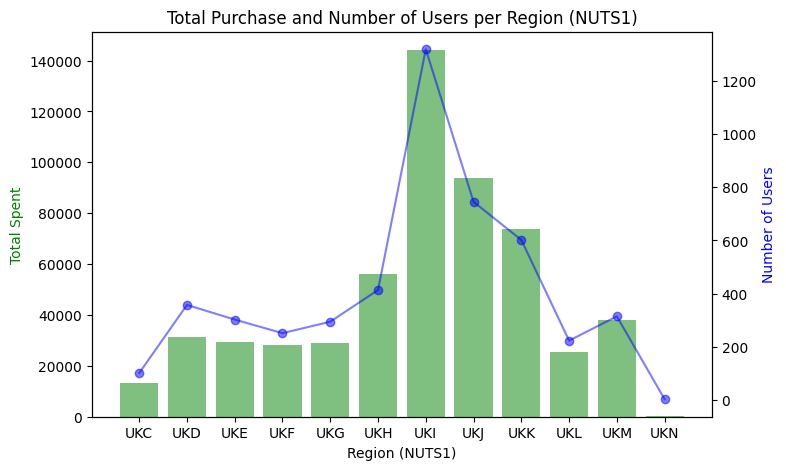

In [20]:
# Group by user_nuts1 and sum the total_spent
purchase_per_region = users_summary.groupby('user_nuts1')['total_spent'].sum().reset_index()

# Calculate the number of users per region
users_per_region = users_summary.groupby('user_nuts1')['user_id'].count().reset_index()
users_per_region.columns = ['user_nuts1', 'num_users']

# Merge the two dataframes
region_summary = pd.merge(purchase_per_region, users_per_region, on='user_nuts1')

# Plot the data
fig, ax1 = plt.subplots(figsize=(8, 5))

ax2 = ax1.twinx()
ax1.bar(region_summary['user_nuts1'], region_summary['total_spent'], color='g', alpha=0.5)
ax2.plot(region_summary['user_nuts1'], region_summary['num_users'], color='b', marker='o', alpha=0.5)

ax1.set_xlabel('Region (NUTS1)')
ax1.set_ylabel('Total Spent', color='g')
ax2.set_ylabel('Number of Users', color='b')
plt.title('Total Purchase and Number of Users per Region (NUTS1)')
plt.xticks(rotation=45)
plt.show()

It'd be interessting to know the number of habitants per region to understand real penetration...

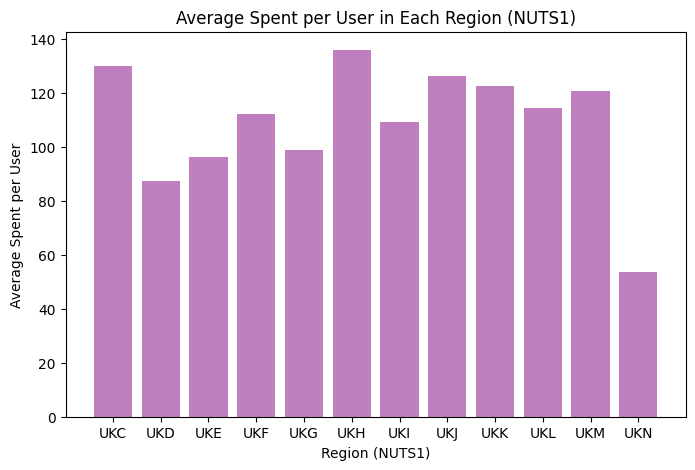

In [ ]:
# Calculate the average price per user in each region
region_summary['avg_spent_per_user'] = region_summary['total_spent'] / region_summary['num_users']

# Plot the average price per user in each region
plt.figure(figsize=(8, 5))
plt.bar(region_summary['user_nuts1'], region_summary['avg_spent_per_user'], color='purple', alpha=0.5)
plt.xlabel('Region (NUTS1)')
plt.ylabel('Average Spent per User')
plt.title('Average Spent per User in Each Region (NUTS1)')
plt.show()

It'd be interesting to check which regions are more rich to contrast the results